In [2]:
import pandas as pd 
import joblib 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.metrics import(
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    PrecisionRecallDisplay
)

In [3]:
df = pd.read_csv("../data/telco_clean.csv")
X = df.drop("Churn Label",axis=1)
y = df["Churn Label"].map({"No":0,"Yes":1})

In [4]:
from sklearn.model_selection import train_test_split 
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
best_model = joblib.load("../models/best_model.pkl")

In [6]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1035
           1       0.97      0.90      0.93       374

    accuracy                           0.97      1409
   macro avg       0.97      0.94      0.95      1409
weighted avg       0.97      0.97      0.96      1409



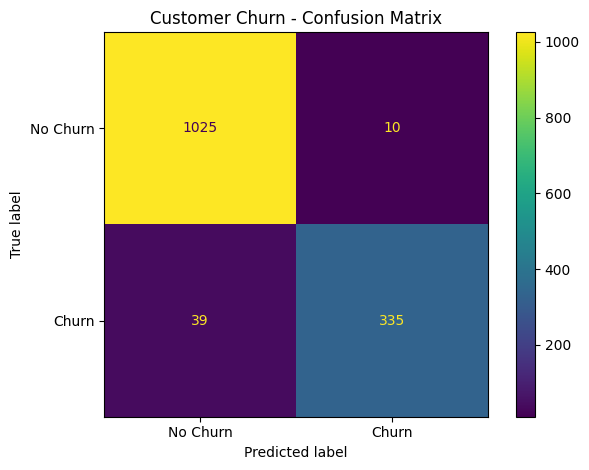

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Customer Churn - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../reports/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

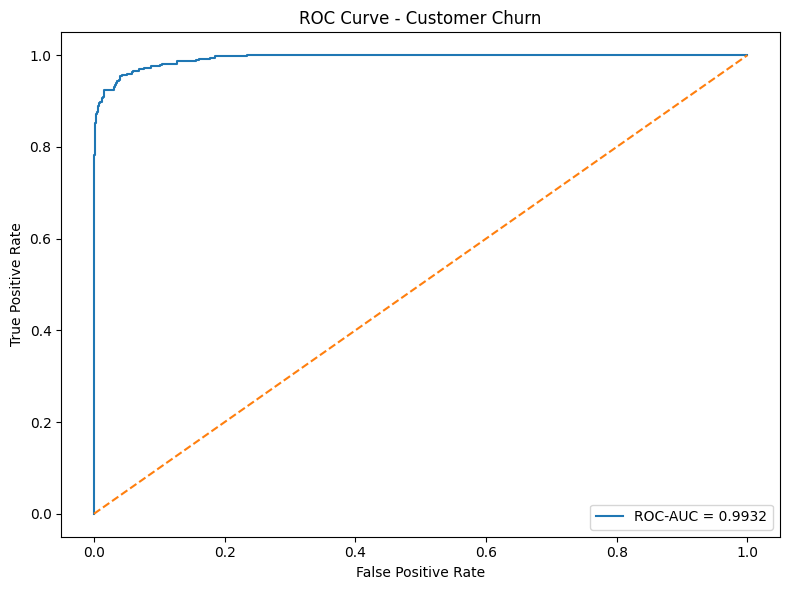

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probability = best_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Customer Churn")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

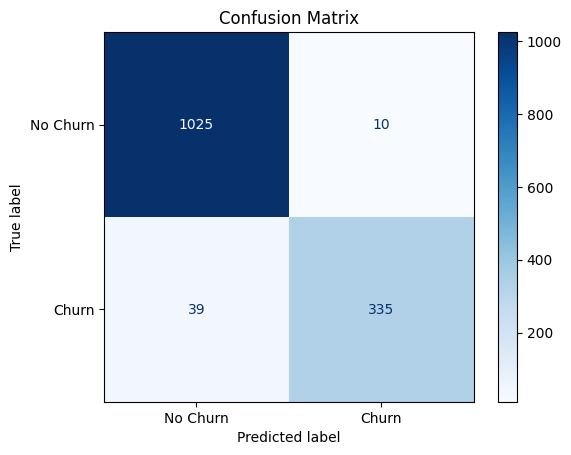

In [10]:
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn","Churn"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

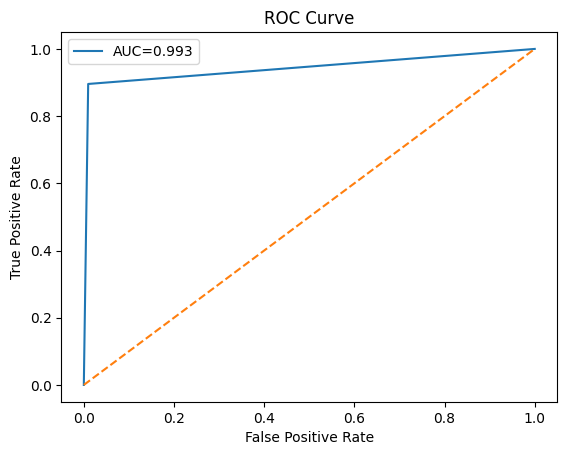

In [11]:
#ROC Curve
fpr , tpr , thershold = roc_curve(y_test,y_pred)
plt.Figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f"AUC={roc_auc_score(y_test,y_prob):.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

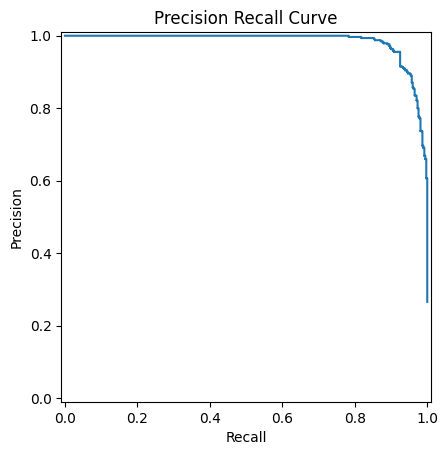

In [12]:
#Precision-Recall Curve
precision,recall,threshold = precision_recall_curve(
    y_test,
    y_prob
)

disp = PrecisionRecallDisplay(
    precision=precision,
    recall=recall
)

disp.plot()

plt.title("Precision Recall Curve")

plt.show()

In [13]:
#Save Predictions
predictions = X_test.copy()

predictions["Actual"] = y_test.values

predictions["Predicted"] = y_pred

predictions["Probability"] = y_prob

predictions.head()

,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Satisfaction Score,Actual,Predicted,Probability
803,Male,74,No,Yes,No,No,0,United States,California,Westlake Village,...,Bank Withdrawal,84.85,3645.60,0.0,0,378.83,4,0,0,0.008728
3549,Female,55,No,No,Yes,Yes,3,United States,California,Mill Creek,...,Bank Withdrawal,109.05,7508.55,0.0,0,1252.56,4,0,0,0.000314
3515,Female,60,No,No,Yes,No,0,United States,California,Stonyford,...,Bank Withdrawal,18.40,1057.85,0.0,0,1592.41,4,0,0,0.000060
5162,Female,62,No,No,Yes,Yes,2,United States,California,Tehachapi,...,Credit Card,26.10,692.55,0.0,0,155.15,3,0,0,0.001698
4642,Female,61,No,No,Yes,Yes,1,United States,California,Weed,...,Credit Card,85.00,5607.75,0.0,130,427.04,3,0,0,0.000322


In [14]:
predictions.to_csv(
    "../reports/predictions.csv",
    index=False
)

In [15]:
print(X_train.columns.tolist())

['Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Country', 'State', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Satisfaction Score']


In [16]:
import json
import pandas as pd

customer = X.iloc[0].copy()

# Convert missing values to None
customer = customer.where(pd.notna(customer), None)

# Convert column names to API/Pydantic names
rename_map = {
    "Under 30": "Under_30",
    "Senior Citizen": "Senior_Citizen",
    "Number of Dependents": "Number_of_Dependents",
    "Zip Code": "Zip_Code",
    "Referred a Friend": "Referred_a_Friend",
    "Number of Referrals": "Number_of_Referrals",
    "Tenure in Months": "Tenure_in_Months",
    "Phone Service": "Phone_Service",
    "Avg Monthly Long Distance Charges": "Avg_Monthly_Long_Distance_Charges",
    "Multiple Lines": "Multiple_Lines",
    "Internet Service": "Internet_Service",
    "Internet Type": "Internet_Type",
    "Avg Monthly GB Download": "Avg_Monthly_GB_Download",
    "Online Security": "Online_Security",
    "Online Backup": "Online_Backup",
    "Device Protection Plan": "Device_Protection_Plan",
    "Premium Tech Support": "Premium_Tech_Support",
    "Streaming TV": "Streaming_TV",
    "Streaming Movies": "Streaming_Movies",
    "Streaming Music": "Streaming_Music",
    "Unlimited Data": "Unlimited_Data",
    "Paperless Billing": "Paperless_Billing",
    "Payment Method": "Payment_Method",
    "Monthly Charge": "Monthly_Charge",
    "Total Charges": "Total_Charges",
    "Total Refunds": "Total_Refunds",
    "Total Extra Data Charges": "Total_Extra_Data_Charges",
    "Total Long Distance Charges": "Total_Long_Distance_Charges",
    "Satisfaction Score": "Satisfaction_Score"
}

customer = customer.rename(index=rename_map)

# Convert NumPy/Pandas values to JSON-compatible values
customer_json = json.loads(customer.to_json())

print(json.dumps(customer_json, indent=2))

{
  "Gender": "Male",
  "Age": 78,
  "Under_30": "No",
  "Senior_Citizen": "Yes",
  "Married": "No",
  "Dependents": "No",
  "Number_of_Dependents": 0,
  "Country": "United States",
  "State": "California",
  "City": "Los Angeles",
  "Zip_Code": 90022,
  "Latitude": 34.02381,
  "Longitude": -118.156582,
  "Population": 68701,
  "Quarter": "Q3",
  "Referred_a_Friend": "No",
  "Number_of_Referrals": 0,
  "Tenure_in_Months": 1,
  "Offer": null,
  "Phone_Service": "No",
  "Avg_Monthly_Long_Distance_Charges": 0.0,
  "Multiple_Lines": "No",
  "Internet_Service": "Yes",
  "Internet_Type": "DSL",
  "Avg_Monthly_GB_Download": 8,
  "Online_Security": "No",
  "Online_Backup": "No",
  "Device_Protection_Plan": "Yes",
  "Premium_Tech_Support": "No",
  "Streaming_TV": "No",
  "Streaming_Movies": "Yes",
  "Streaming_Music": "No",
  "Unlimited_Data": "No",
  "Contract": "Month-to-Month",
  "Paperless_Billing": "Yes",
  "Payment_Method": "Bank Withdrawal",
  "Monthly_Charge": 39.65,
  "Total_Charges": 